In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shashwatkumarjha/maskcoord/MaskCoord.mp4


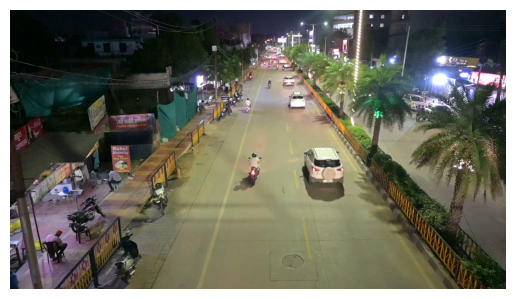

In [2]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture("/kaggle/input/datasets/shashwatkumarjha/maskcoord/MaskCoord.mp4")

ret, frame = cap.read()

if ret:
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis("off")

In [3]:
import cv2

cap = cv2.VideoCapture("/kaggle/input/datasets/shashwatkumarjha/maskcoord/MaskCoord.mp4")

ret, frame = cap.read()

if ret:
    cv2.imwrite("/kaggle/working/frame.jpg", frame)
    print("Frame saved successfully")
else:
    print("Frame not captured")

Frame saved successfully


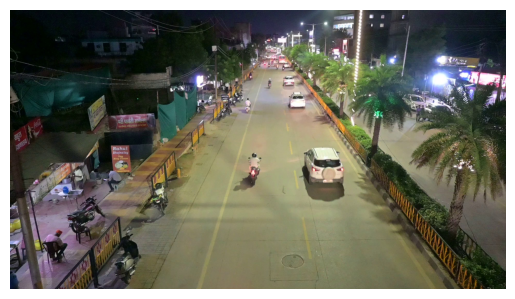

In [4]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/kaggle/working/frame.jpg")

if img is None:
    print("Image not loaded")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")

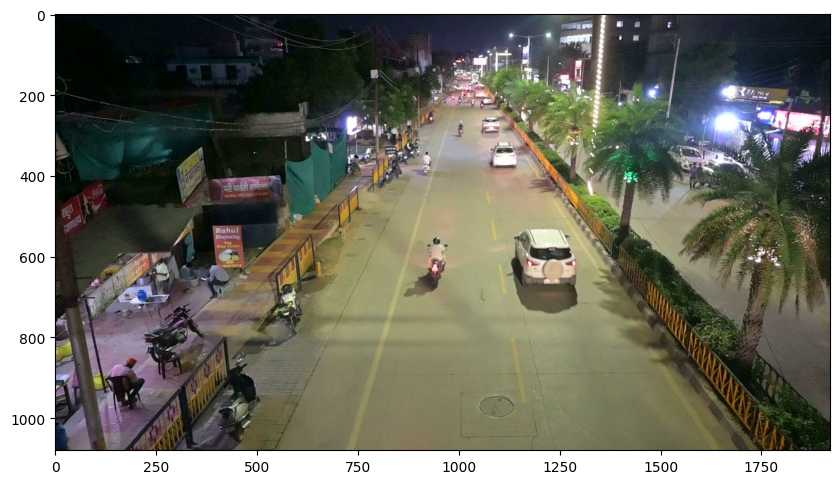

In [5]:
fig, ax = plt.subplots(figsize=(10,6))
ax.imshow(img)

def onclick(event):
    if event.xdata and event.ydata:
        x = int(event.xdata)
        y = int(event.ydata)
        print(f"({x},{y})")

fig.canvas.mpl_connect('button_press_event', onclick)

plt.show()

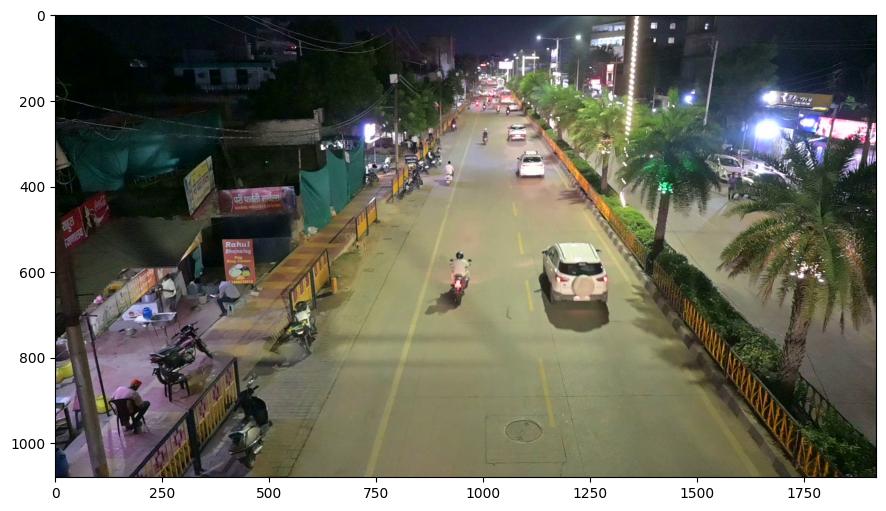

In [6]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/kaggle/working/frame.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,6))
plt.imshow(img)
plt.axis("on")   # shows coordinate grid
plt.show()

In [7]:
import cv2

cap = cv2.VideoCapture("/kaggle/input/datasets/shashwatkumarjha/maskcoord/MaskCoord.mp4")

ret, frame = cap.read()

if ret:
    cv2.imwrite("/kaggle/working/frame.jpg", frame)
    print("Frame saved")

Frame saved


In [8]:
import numpy as np

pts = np.array([
[540,1066],
[972,216],
[1080,216],
[1650,1066]
])

In [9]:
mask = np.zeros(frame.shape[:2], dtype=np.uint8)

cv2.fillPoly(mask,[pts],255)

masked = cv2.bitwise_and(frame,frame,mask=mask)

In [10]:
import cv2
import numpy as np

cap = cv2.VideoCapture("/kaggle/input/datasets/shashwatkumarjha/maskcoord/MaskCoord.mp4")

ret, frame = cap.read()

pts = np.array([
    [540,1066],
    [972,216],
    [1080,216],
    [1650,1066]
], np.int32)

mask = np.zeros(frame.shape[:2], dtype=np.uint8)

cv2.fillPoly(mask, [pts], 255)

roi = cv2.bitwise_and(frame, frame, mask=mask)

# save ROI image
cv2.imwrite("/kaggle/working/roi_image.jpg", roi)

print("ROI saved")

ROI saved


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

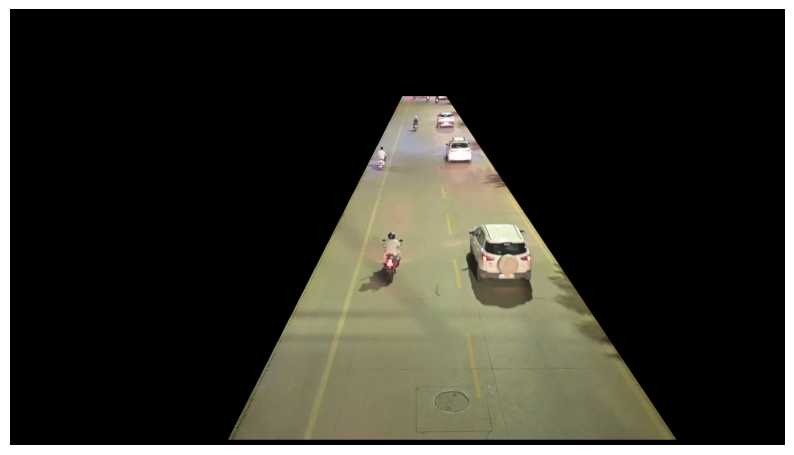

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

cap = cv2.VideoCapture("/kaggle/input/datasets/shashwatkumarjha/maskcoord/MaskCoord.mp4")

ret, frame = cap.read()

pts = np.array([
    [540,1066],
    [972,216],
    [1080,216],
    [1650,1066]
], np.int32)

mask = np.zeros(frame.shape[:2], dtype=np.uint8)

cv2.fillPoly(mask, [pts], 255)

masked_frame = cv2.bitwise_and(frame, frame, mask=mask)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(masked_frame, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [12]:
import cv2
import numpy as np

video_path = "/kaggle/input/datasets/shashwatkumarjha/maskcoord/MaskCoord.mp4"

cap = cv2.VideoCapture(video_path)

# Get video properties
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)

# Video writer
out = cv2.VideoWriter(
    "/kaggle/working/masked_video.mp4",
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (width, height)
)

# ROI polygon
pts = np.array([
    [540,1066],
    [972,216],
    [1080,216],
    [1650,1066]
], np.int32)

# Create mask once
mask = np.zeros((height, width), dtype=np.uint8)
cv2.fillPoly(mask, [pts], 255)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    masked = cv2.bitwise_and(frame, frame, mask=mask)

    out.write(masked)

cap.release()
out.release()

print("Masked video saved to /kaggle/working/masked_video.mp4")

Masked video saved to /kaggle/working/masked_video.mp4
